In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'usecase':
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))


# Use Case 4: Low-Rate / Near-Zero Model Selection

## Business Scenario

A rates desk or model-validation team needs to mark a swaption in a **near-zero / slightly negative forward-rate environment**.
In this regime, standard lognormal Black can become awkward or invalid, so the desk must choose among:

- `shifted Black`
- `shifted SABR`
- `Bachelier`

This use case focuses on **model choice**, not on claiming that one model is always right.
The purpose is to show how premium and interpretation change when the underlying forward swap rate is close to or below zero.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from swaption_pricing.pricing.european import price_swaption_bachelier
from swaption_pricing.pricing.european import price_swaption_shifted_black
from swaption_pricing.pricing.european import SabrParams, price_swaption_with_shifted_sabr
from swaption_pricing.core import forward_swap_rate, swap_annuity
from swaption_pricing.types import CurvePoint, SwaptionSpec


## Synthetic Low-Rate Curve Setup

Unlike the first three use cases, this notebook intentionally uses a **synthetic low-rate curve**.
The reason is practical: the goal here is to force a regime where the forward swap rate becomes close to or below zero,
so that model-choice differences are visible and easy to interpret.

This is still a realistic stress-style exercise because low-rate and negative-rate scenarios are exactly where shifted and normal-vol models matter.


In [3]:
curve = [
    CurvePoint(0.25, -0.0020),
    CurvePoint(0.50, -0.0022),
    CurvePoint(1.00, -0.0023),
    CurvePoint(2.00, -0.0025),
    CurvePoint(3.00, -0.0026),
    CurvePoint(5.00, -0.0028),
    CurvePoint(7.00, -0.0030),
    CurvePoint(10.00, -0.0031),
]

curve_df = pd.DataFrame([
    {'maturity': point.maturity, 'zero_rate': point.zero_rate}
    for point in curve
])
curve_df


,maturity,zero_rate
0,0.25,-0.0020
1,0.50,-0.0022
2,1.00,-0.0023
3,2.00,-0.0025
4,3.00,-0.0026
5,5.00,-0.0028
6,7.00,-0.0030
7,10.00,-0.0031


## Trade Specification

Representative low-rate comparison trade:

- Notional: `USD 50,000,000`
- Expiry: `2Y`
- Underlying swap tenor: `5Y`
- Option type: `receiver`
- Strike: `0.00%`

The zero strike is deliberate: it makes the trade a natural boundary case for low-rate model comparison.


In [4]:
notional = 50_000_000.0
expiry = 2.0
tenor = 5.0
pay_frequency = 1
option_type = 'receiver'
strike = 0.0

spec = SwaptionSpec(
    notional=notional,
    expiry=expiry,
    tenor=tenor,
    strike=strike,
    pay_frequency=pay_frequency,
    option_type=option_type,
)

forward = forward_swap_rate(curve, expiry, tenor, pay_frequency)
annuity = swap_annuity(curve, expiry, tenor, pay_frequency)

black_vol = 0.22
normal_vol = 0.0075
sabr_params = SabrParams(alpha=0.012, beta=0.50, rho=-0.30, nu=0.45)
shift_values = [0.02, 0.03, 0.05]

trade_summary = pd.DataFrame([
    {
        'forward_swap_rate': forward,
        'annuity': annuity,
        'strike': strike,
        'black_vol': black_vol,
        'normal_vol': normal_vol,
    }
])
trade_summary


,forward_swap_rate,annuity,strike,black_vol,normal_vol
0,-0.003196,5.071562,0.0,0.22,0.0075


## Cross-Model Pricing by Shift Choice

For shifted-lognormal models, the shift itself becomes part of the modeling choice.
Bachelier, by contrast, does not require a shift because the normal-vol framework naturally accepts negative forwards and strikes.


In [5]:
pricing_rows = []
for shift in shift_values:
    shifted_black_price = price_swaption_shifted_black(curve, spec, black_vol, shift)
    shifted_sabr_price, shifted_sabr_vol = price_swaption_with_shifted_sabr(curve, spec, sabr_params, shift)
    bachelier_price = price_swaption_bachelier(curve, spec, normal_vol)
    pricing_rows.append({
        'shift': shift,
        'shifted_black_price': shifted_black_price,
        'shifted_sabr_implied_vol': shifted_sabr_vol,
        'shifted_sabr_price': shifted_sabr_price,
        'bachelier_price': bachelier_price,
    })

pricing_df = pd.DataFrame(pricing_rows)
pricing_df


,shift,shifted_black_price,shifted_sabr_implied_vol,shifted_sabr_price,bachelier_price
0,0.02,1.069176e+06,0.090449,834174.442529,1.526585e+06
1,0.03,1.352777e+06,0.071458,858862.637522,1.526585e+06
2,0.05,1.956326e+06,0.054202,911666.198095,1.526585e+06


## Strike Sensitivity in a Near-Zero Regime

To make the comparison more tangible, we also vary the strike around zero.
This shows how low-rate model differences persist even when the trade moves from slightly negative strikes to slightly positive strikes.


In [6]:
strike_grid = [-0.0050, -0.0025, 0.0000, 0.0025]
reference_shift = 0.03
strike_rows = []
for strike_value in strike_grid:
    strike_spec = SwaptionSpec(
        notional=notional,
        expiry=expiry,
        tenor=tenor,
        strike=strike_value,
        pay_frequency=pay_frequency,
        option_type=option_type,
    )
    shifted_black_price = price_swaption_shifted_black(curve, strike_spec, black_vol, reference_shift)
    shifted_sabr_price, shifted_sabr_vol = price_swaption_with_shifted_sabr(curve, strike_spec, sabr_params, reference_shift)
    bachelier_price = price_swaption_bachelier(curve, strike_spec, normal_vol)
    strike_rows.append({
        'strike': strike_value,
        'shifted_black_price': shifted_black_price,
        'shifted_sabr_implied_vol': shifted_sabr_vol,
        'shifted_sabr_price': shifted_sabr_price,
        'bachelier_price': bachelier_price,
    })

strike_df = pd.DataFrame(strike_rows)
strike_df


,strike,shifted_black_price,shifted_sabr_implied_vol,shifted_sabr_price,bachelier_price
0,-0.0050,6.033674e+05,0.083022,1.312791e+05,8.597687e+05
1,-0.0025,9.422910e+05,0.073292,3.814958e+05,1.163572e+06
2,0.0000,1.352777e+06,0.071458,8.588626e+05,1.526585e+06
3,0.0025,1.822485e+06,0.075334,1.455546e+06,1.946324e+06


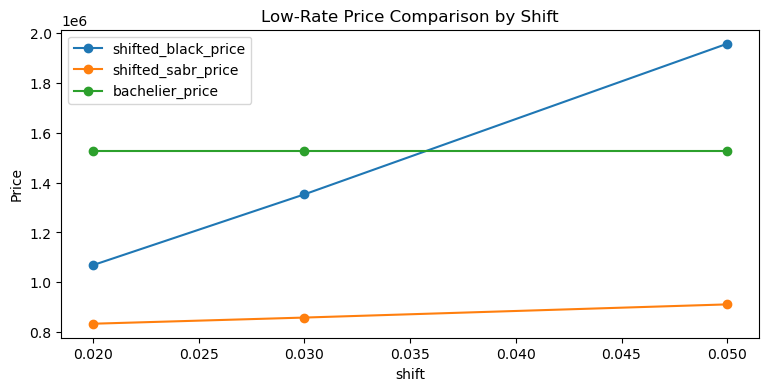

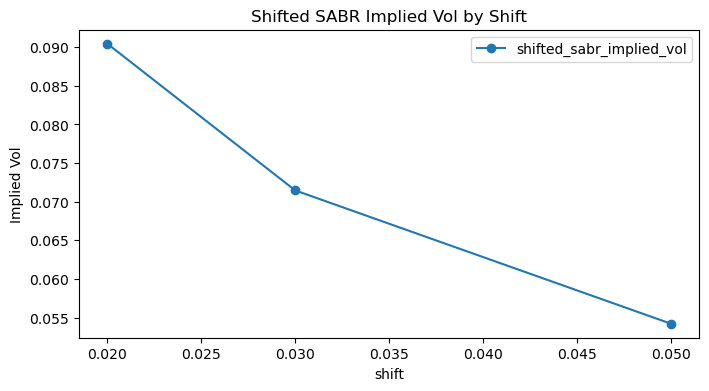

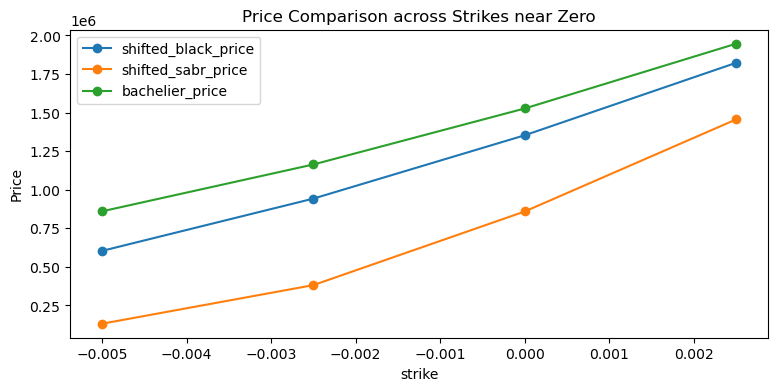

In [7]:
ax = pricing_df.plot(x='shift', y=['shifted_black_price', 'shifted_sabr_price', 'bachelier_price'], marker='o', figsize=(9, 4), title='Low-Rate Price Comparison by Shift')
ax.set_ylabel('Price')
plt.show()

ax = pricing_df.plot(x='shift', y='shifted_sabr_implied_vol', marker='o', figsize=(8, 4), title='Shifted SABR Implied Vol by Shift')
ax.set_ylabel('Implied Vol')
plt.show()

ax = strike_df.plot(x='strike', y=['shifted_black_price', 'shifted_sabr_price', 'bachelier_price'], marker='o', figsize=(9, 4), title='Price Comparison across Strikes near Zero')
ax.set_ylabel('Price')
plt.show()


## Model-Selection Interpretation

- The forward swap rate in this setup is slightly negative, which immediately stresses standard lognormal assumptions.
- `shifted Black` remains usable, but the premium depends materially on the chosen shift.
- `shifted SABR` adds smile dynamics on top of the shifted-lognormal framework, so both the shift and the smile parameters matter.
- `Bachelier` does not require a shift and therefore offers a cleaner normal-vol interpretation in near-zero or negative-rate regimes.
- This is why low-rate environments are not just a pricing problem but a **model-governance problem**: the desk must choose which framework best matches market quoting conventions and risk interpretation.
- In a real production setup, the final model choice would also depend on available market vol conventions, validation policy, and how the desk hedges vega and curve risk.
